In [1]:
import pandas as pd
inventory = pd.read_csv('/Users/xiezexing/Downloads/T_F41SCHEDULE_B43_with_missing.zip')

/var/folders/mk/n_ss_mb947xcn82pbzlqvzz00000gn/T/ipykernel_83174/1615822641.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('/Users/xiezexing/Downloads/T_F41SCHEDULE_B43_with_missing.zip')


1. Investigate the missing data in this dataset. Specifically, for each of the following variables that have missing data, decide if any imputation is possible. Give your reasoning and code for how you decide to impute missing values.

In [2]:
# import the package for inpsecting missing data
import sys
!{sys.executable} -m pip install missingno
import missingno as msno

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


<Axes: >

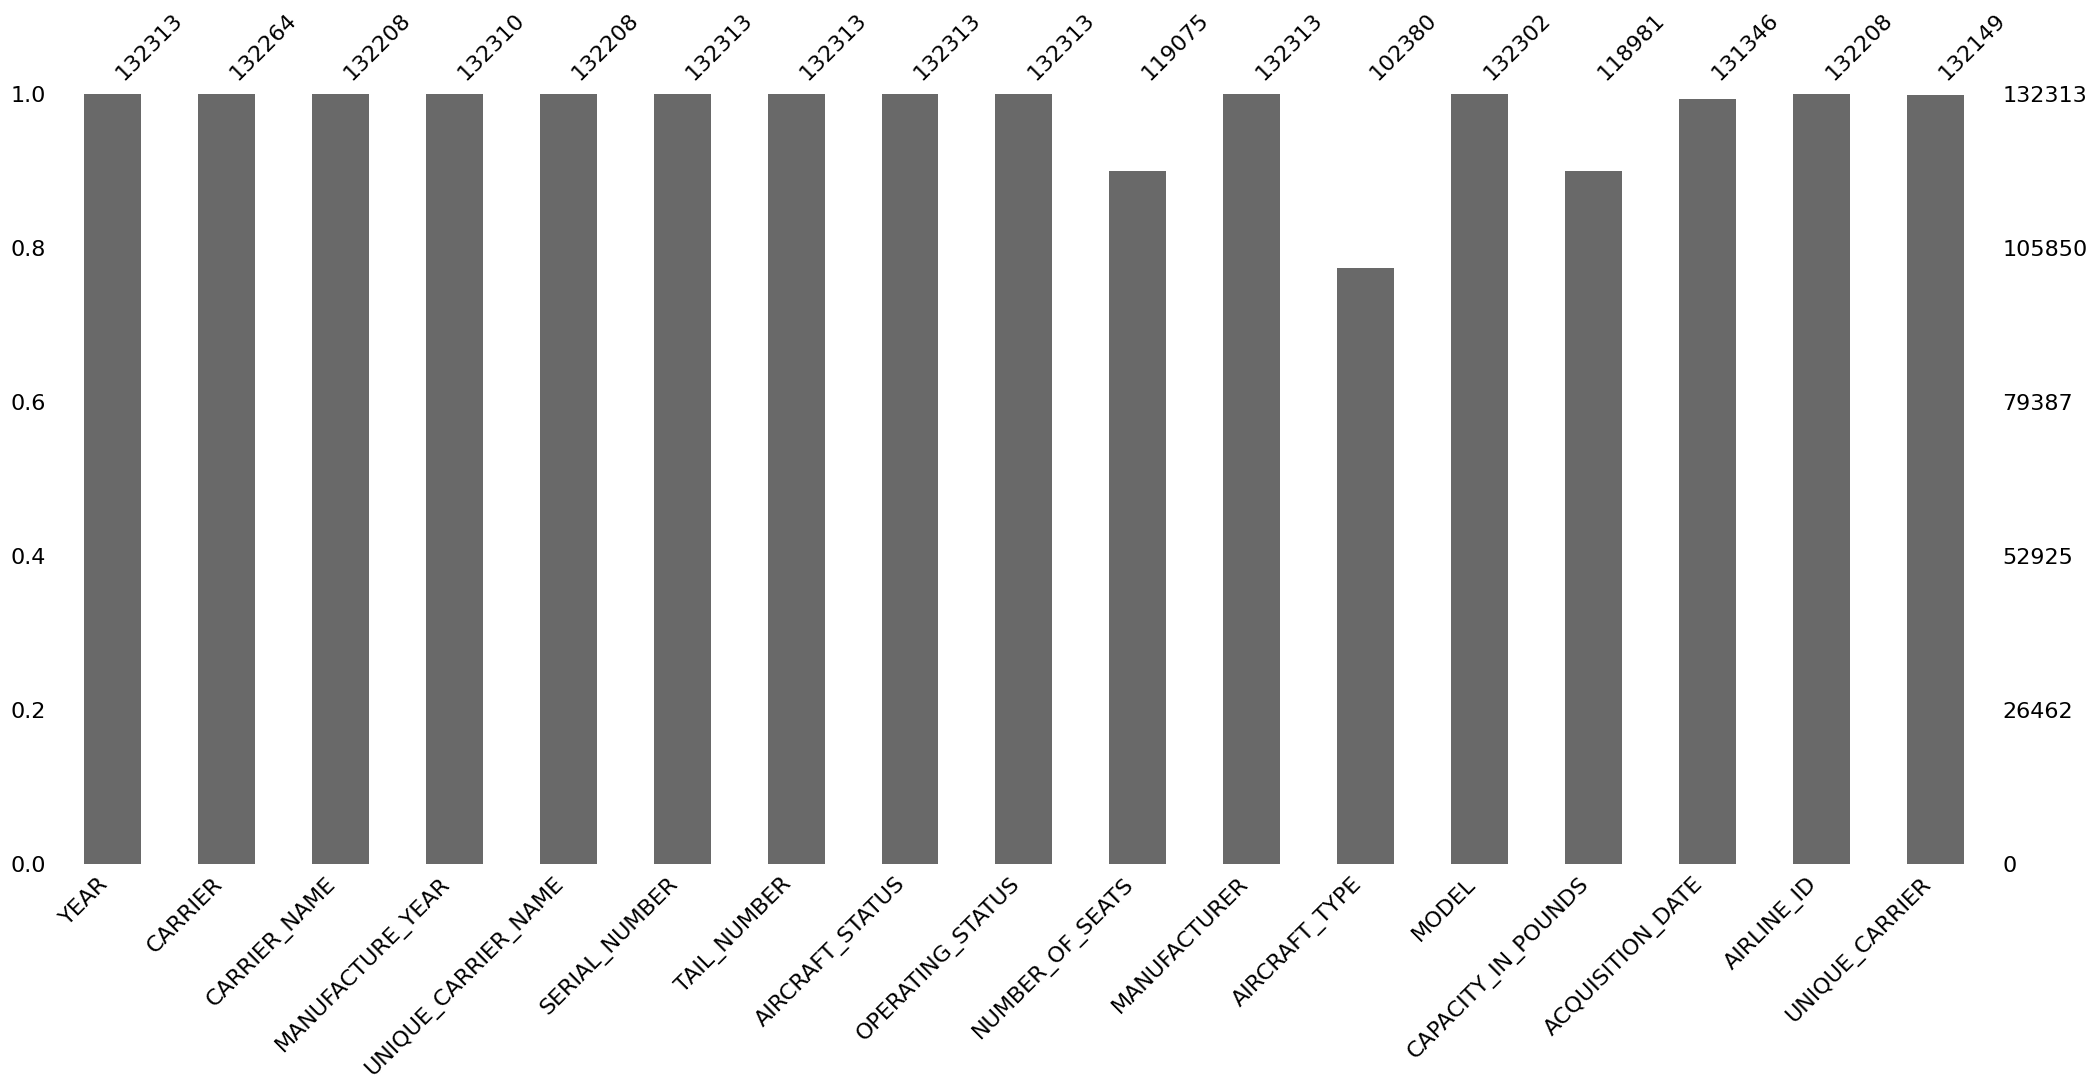

In [3]:
# We first look at the missing data for each column, which are Carrier, Carrier_Name, Manufacture_year, Unqiue_Carrier_Name, Number of seats, aircraft_type, Model, capacity in pound, acquisition_date, airline ID, and Unqiue_Carrier
msno.bar(inventory)

In [4]:
# Investigate the columns that we are only interested so far
# 1:
investigation = inventory.loc[:,["CARRIER","CARRIER_NAME","MANUFACTURE_YEAR","NUMBER_OF_SEATS","CAPACITY_IN_POUNDS","AIRLINE_ID"]]
investigation[investigation.isna().any(axis = 1)].head(1000)
investigation.isna().corr()


,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,NUMBER_OF_SEATS,CAPACITY_IN_POUNDS,AIRLINE_ID
CARRIER,1.000000,-0.000542,-0.000092,0.057727,-0.006443,-0.000542
CARRIER_NAME,-0.000542,1.000000,-0.000134,-0.009397,-0.009434,1.000000
MANUFACTURE_YEAR,-0.000092,-0.000134,1.000000,-0.001588,0.008952,-0.000134
NUMBER_OF_SEATS,0.057727,-0.009397,-0.001588,1.000000,0.039672,-0.009397
CAPACITY_IN_POUNDS,-0.006443,-0.009434,0.008952,0.039672,1.000000,-0.009434
AIRLINE_ID,-0.000542,1.000000,-0.000134,-0.009397,-0.009434,1.000000


<Axes: >

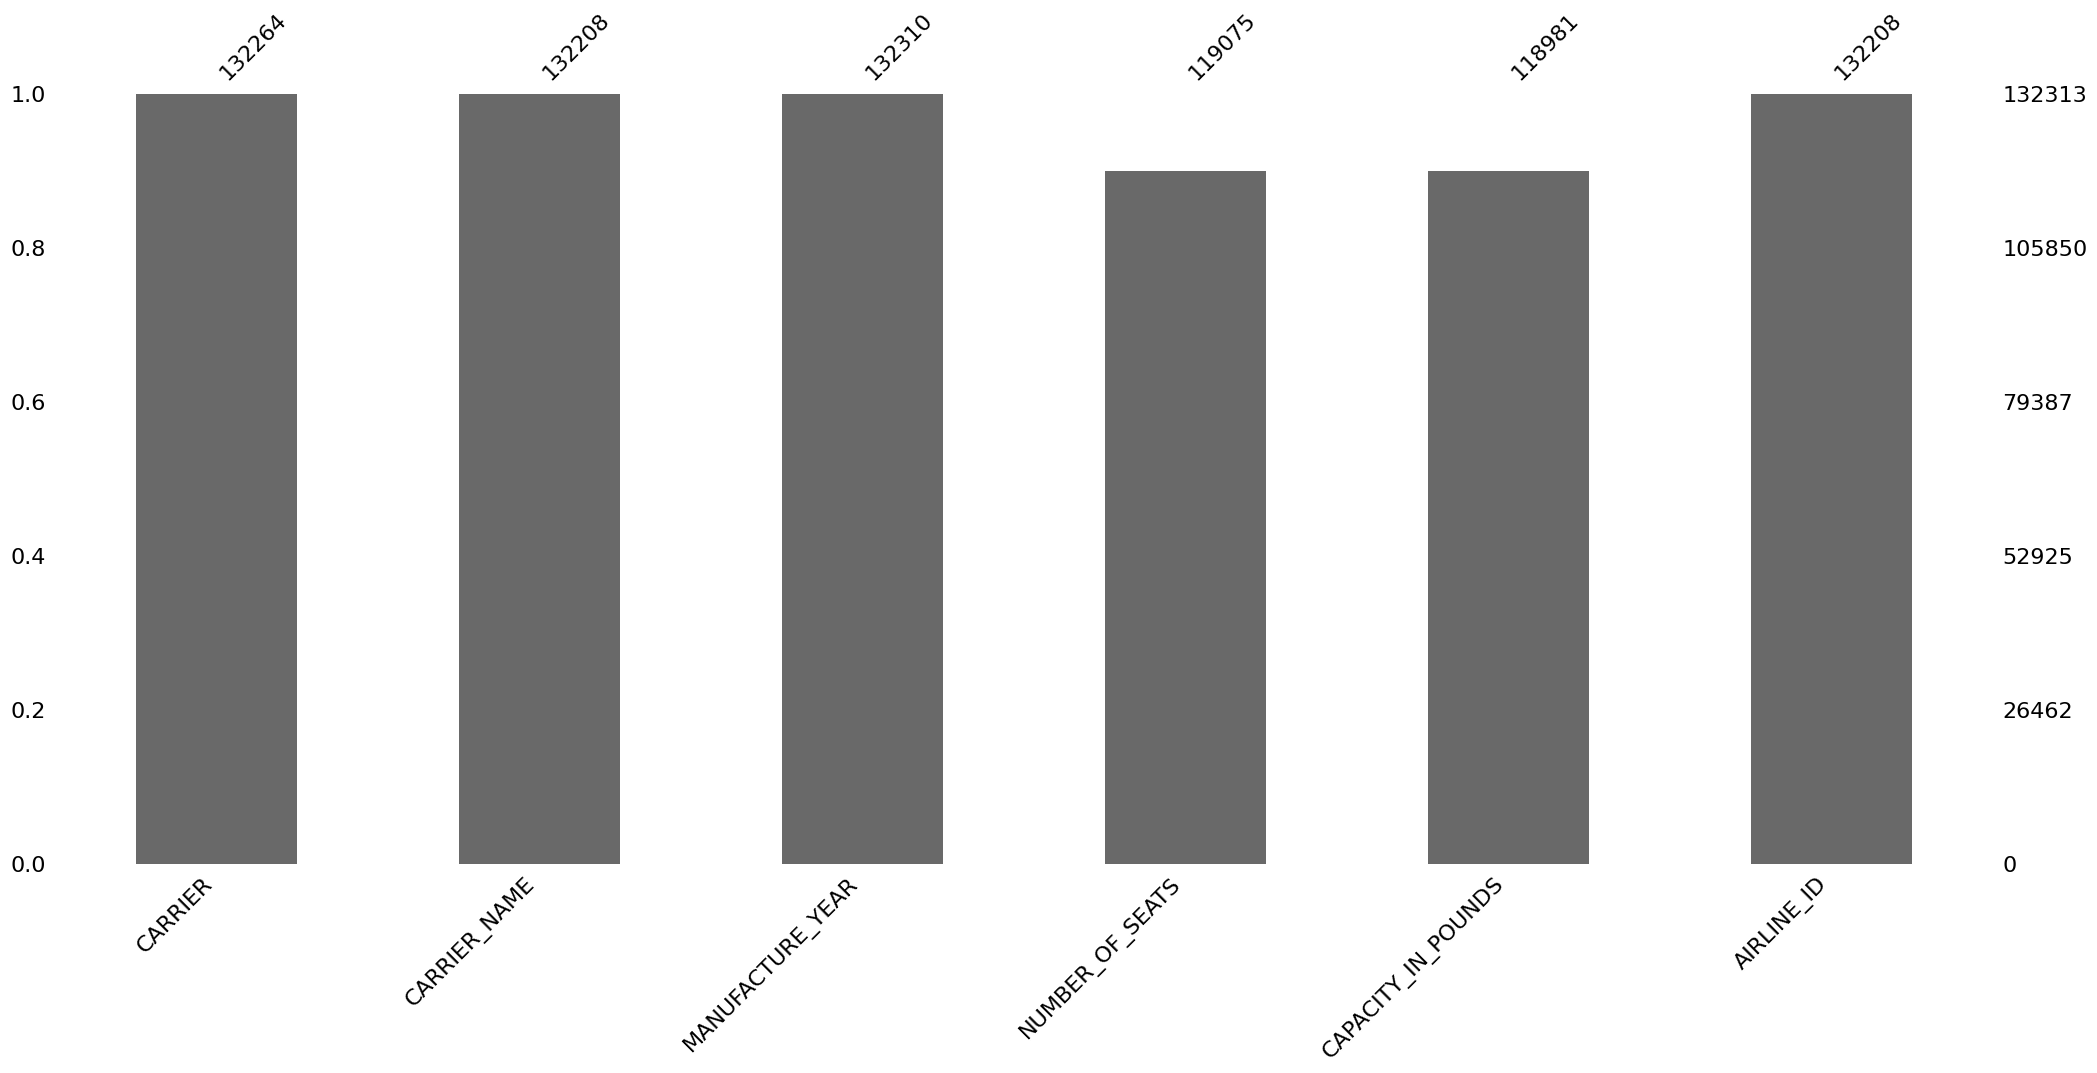

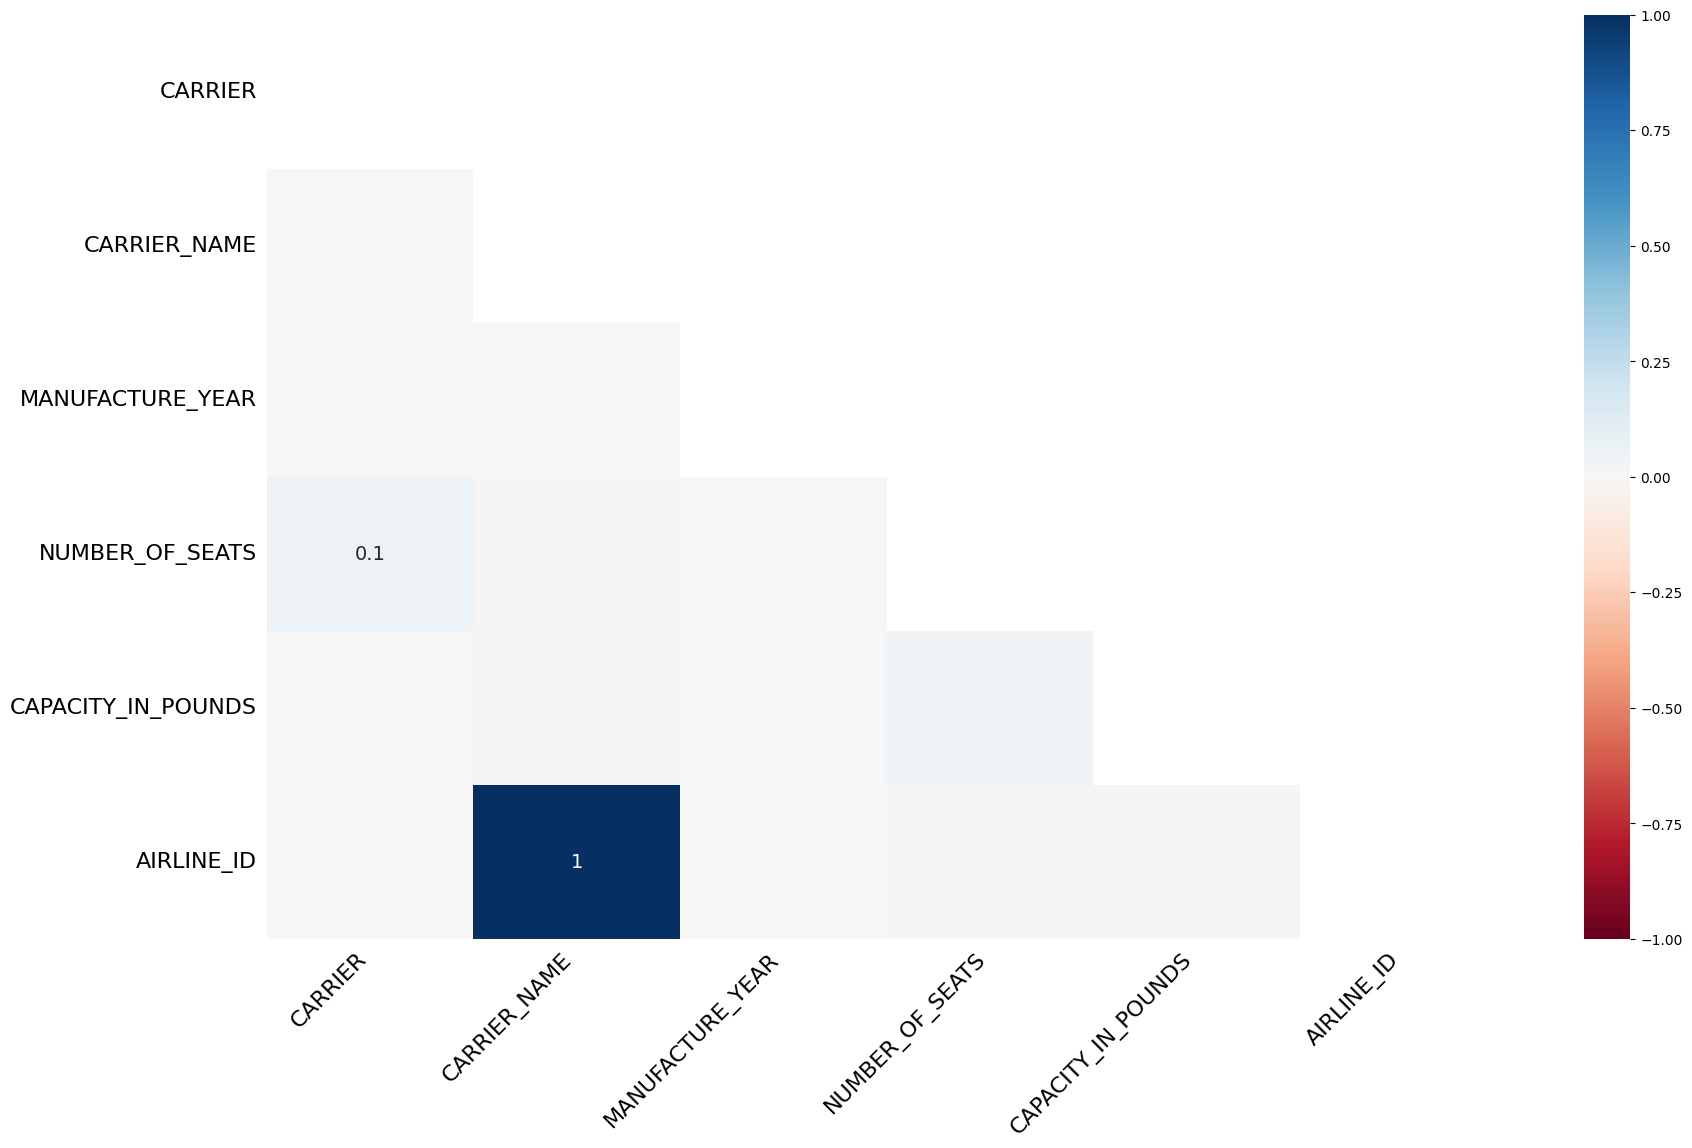

In [5]:
msno.bar(investigation)
msno.heatmap(investigation)

One of the first thing I noticed is that there is a perfect correlation between carrier_name and airline_id, which implies that either both are present or both are missing; this makes sense since airline_id identifies which carrier it is. After inspection of the data, I decide to not impute missing data for Carrier, Carrier_Name, and Airline_ID. Several reasons are following. Firstly, Carrier is not a unique identification since it can be used by many different airlines; therefore, imputation is not reliable across the whole dataset. Secondly, Carrier_Name and Airline_ID are perfectly correlated shown in heatmap generated above. Therefore, it is impossible to recover the missing data using either one of them. However, I am going to recover one specific but unique airline: North American Airline. This airline has missing data for UniqueCarrier and Carrier, but as the code shown below, the Carrier "NA" has only been used by this specific airline, and thereby, it could be used as UniqueCarrier. Therefore, I am going to fill up the Unqiue_Carrier Column and Carrier Column

In [6]:
# Only North American Airline use Carrier NA
inventory.loc[
    inventory["CARRIER"] == "NA ",
    ["AIRLINE_ID", "CARRIER_NAME", "UNIQUE_CARRIER_NAME"]
].drop_duplicates()

,AIRLINE_ID,CARRIER_NAME,UNIQUE_CARRIER_NAME
26207,20415.0,North American Airlines,North American Airlines


In [7]:
# the Unique_Carrier is missing for this airline
inventory[inventory["AIRLINE_ID"] == 20415][
    ["YEAR", "AIRLINE_ID", "CARRIER", "UNIQUE_CARRIER", "CARRIER_NAME", "UNIQUE_CARRIER_NAME"]
].drop_duplicates()

,YEAR,AIRLINE_ID,CARRIER,UNIQUE_CARRIER,CARRIER_NAME,UNIQUE_CARRIER_NAME
11776,2007,20415.0,NaN,NaN,North American Airlines,North American Airlines
19009,2008,20415.0,NaN,NaN,North American Airlines,North American Airlines
26207,2009,20415.0,NA,NaN,North American Airlines,North American Airlines
33678,2010,20415.0,NaN,NaN,North American Airlines,North American Airlines
40715,2011,20415.0,NaN,NaN,North American Airlines,North American Airlines
47729,2012,20415.0,NaN,NaN,North American Airlines,North American Airlines
54546,2013,20415.0,NaN,NaN,North American Airlines,North American Airlines


In [8]:
# Fill the column 
inventory_processed = inventory.copy()
mask = (
    (inventory_processed["UNIQUE_CARRIER"].isna() |
    (inventory_processed["CARRIER"].isna())) &
    (inventory_processed["CARRIER_NAME"] == "North American Airlines")
)

inventory_processed.loc[mask, ["UNIQUE_CARRIER", "CARRIER"]] = "NA"
inventory_processed[inventory_processed["AIRLINE_ID"] == 20415][
    ["YEAR", "AIRLINE_ID", "CARRIER", "UNIQUE_CARRIER", "CARRIER_NAME", "UNIQUE_CARRIER_NAME"]
].drop_duplicates()

,YEAR,AIRLINE_ID,CARRIER,UNIQUE_CARRIER,CARRIER_NAME,UNIQUE_CARRIER_NAME
11776,2007,20415.0,NA,NA,North American Airlines,North American Airlines
19009,2008,20415.0,NA,NA,North American Airlines,North American Airlines
26207,2009,20415.0,NA,NA,North American Airlines,North American Airlines
33678,2010,20415.0,NA,NA,North American Airlines,North American Airlines
40715,2011,20415.0,NA,NA,North American Airlines,North American Airlines
47729,2012,20415.0,NA,NA,North American Airlines,North American Airlines
54546,2013,20415.0,NA,NA,North American Airlines,North American Airlines


Next, we look at the possible imputation for Capacity in Pound and Number_Of_seats. Firstly, I think that they are in the category of MAR missingness since these two variables are aircraft-capacity characteristic, so whether they are missing is usually related to observed aircraft information such as aircraft_type or Model. For example, some aircrafts are more passenger_oriented but some are more cargo_oriented; therefore, I decide to use median imputation method, so that it is less sensitive to the extreme values than the mean. 

In [9]:
# Impute the data for column Capacity_IN_Pound and Number of Seats
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy='median')

inventory_processed[["CAPACITY_IN_POUNDS", "NUMBER_OF_SEATS"]] = median_imputer.fit_transform(
    inventory_processed[["CAPACITY_IN_POUNDS", "NUMBER_OF_SEATS"]]
)

For the column of manufacture year, I think it is best to use median imputation method because manufacture year is likely to be MAR; that is, the data missing is likely dependent on observed aircraft information, and it is unlikely to be random. Therefore, years can have outlier or skew; it is safer to use median. 

In [10]:
# Fill out the data
inventory_processed[["MANUFACTURE_YEAR"]] = median_imputer.fit_transform(
    inventory_processed[["MANUFACTURE_YEAR"]]
)

2. Inspect the columns MANUFACTURER, MODEL, AIRCRAFT_STATUS, and OPERATING_STATUS. Decide, for each column, if transformation or standardization of data are required. Give your reasoning and code if you decide to transform the data.

In [11]:
# Start with inspection
for col in ["MANUFACTURER", "MODEL", "AIRCRAFT_STATUS", "OPERATING_STATUS"]:
    print(inventory[col].value_counts(dropna=False).head(30))


MANUFACTURER
BOEING                                                                              15922
Embraer                                                                             11508
THEBOEINGCO                                                                          9223
Bombardier                                                                           8871
Boeing                                                                               8392
BoeingCo                                                                             7446
AIRBUS                                                                               7179
AirbusIndustries                                                                     6967
BOEINGCOMPANY                                                                        6767
Airbus                                                                               5289
CESSNA                                                                               41

As the output shown above, the standarization and transformation is needed for every column. For example, for the manufacture column, there are so many versions of Boeing: BOEING, BOEINGCOMPANY......; To me, they are basically the same thing and same company. Therefore, there has to be one specific boeing name. Also, there might be some spaces after the name just like North American Airline where their carrier is named as "NA " instead of "NA". For the model perspective, I didn't catch so many issues but the issue of space still needs to be considered here. Furthermore, for the Aircraft Status, there needs to be case standardization; for example, b for B, a for A, o for 0. I will assume they are the same thing since on the website provided, it didn't tell us they should be regarded as different meanings. Lastly, for opertaing_status, case standardization is also needed for Y for y.   

In [12]:
# For Manufacture 
# Step 1: remove leading/trailing spaces
inventory_processed["MANUFACTURER"] = inventory_processed["MANUFACTURER"].str.strip()

# Step 2: make everything uppercase
inventory_processed["MANUFACTURER"] = inventory_processed["MANUFACTURER"].str.upper()

# Step 3: remove spaces inside names
inventory_processed["MANUFACTURER"] = inventory_processed["MANUFACTURER"].str.replace(" ", "", regex=False)

# Step 4: manual replacements for big wins
inventory_processed["MANUFACTURER"] = inventory_processed["MANUFACTURER"].replace({
    "THEBOEINGCO": "BOEING",
    "THEBOEINGCOMPANY": "BOEING",
    "BOEINGCO": "BOEING",
    "BOEINGCO.": "BOEING",
    "AIRBUSINDUSTRIE": "AIRBUS",
    "AIRBUSINDUSTRIES": "AIRBUS",
    "AIRBUSCOMPANY": "AIRBUS",
    "MCDONNELLDOUGLAS": "MCDONNELLDOUGLAS",
    "MCDONNELDOUGLAS": "MCDONNELLDOUGLAS",
    "MCDONNELL-DOUGLAS": "MCDONNELLDOUGLAS",
    "MCDO": "MCDONNELLDOUGLAS",
    "MCDONNELL-DOUGLAS" : "MCDONNELLDOUGLAS",
    "MCDONNELLDOUGLASMD11-F": "MCDONNELLDOUGLAS"
    
})

In [13]:
# For Model
# Step 1: remove spaces
inventory_processed["MODEL"] = inventory_processed["MODEL"].str.strip()
# Step 2: uppercase
inventory_processed["MODEL"] = inventory_processed["MODEL"].str.upper()

In [14]:
# For Aircraft 
inventory_processed["AIRCRAFT_STATUS"] = inventory_processed["AIRCRAFT_STATUS"].str.strip()
inventory_processed["AIRCRAFT_STATUS"] = inventory_processed["AIRCRAFT_STATUS"].str.upper()

In [15]:
# For Operating Status
inventory_processed["OPERATING_STATUS"] = inventory_processed["OPERATING_STATUS"].str.strip()
inventory_processed["OPERATING_STATUS"] = inventory_processed["OPERATING_STATUS"].str.upper()

3. Remove data rows that still have missing values. Report the amount of remaining data you obtained.

In [16]:
# remove rows that still have any missing value
inventory_final = inventory_processed.dropna()
# remove the empty string for the column Operating Status
inventory_final = inventory_final[inventory_final["OPERATING_STATUS"] != ""]

# report remaining data size
print(inventory_final.shape)
# there are 101304 data points

(101304, 17)


4. Transformation and derivative variables

For the columns NUMBER_OF_SEATS and CAPACITY_IN_POUNDS, check the skewness in the variable and plot a histogram for each variable.
The Box-Cox transformation (scipy.stats.boxcox) is one possible way to transform variables into a “more-normal-like” variable. Apply the Box-Cox transformation for these two columns and save them as new columns, i.e. XXXXXXXXX_BOXCOX.
Plot a histogram for each transformed variable.
Describe what you observe before and after transformation.

In [17]:
# Checking the skewness 
import scipy.stats as sps
import matplotlib.pyplot as plt
inventory_final.describe()


,YEAR,MANUFACTURE_YEAR,NUMBER_OF_SEATS,CAPACITY_IN_POUNDS,AIRLINE_ID
count,101304.000000,101304.000000,101304.000000,101304.000000,101304.000000
mean,2016.713654,2001.883450,99.030236,71266.179953,20057.415216
std,4.041095,44.863993,60.798410,88255.811850,388.540952
min,2010.000000,0.000000,0.000000,0.000000,19393.000000
25%,2013.000000,1998.000000,50.000000,36200.000000,19805.000000
50%,2017.000000,2003.000000,108.000000,42380.000000,19977.000000
75%,2020.000000,2010.000000,150.000000,76192.000000,20366.000000
max,2023.000000,2756.000000,190.000000,875000.000000,22085.000000


For the variable number of seats, the mean is slightly less than the median, indicating slightly left-skewed.
For the variable capacity in pounds, the mean is greater the the median by a lot, indicating heavily right-skewed.

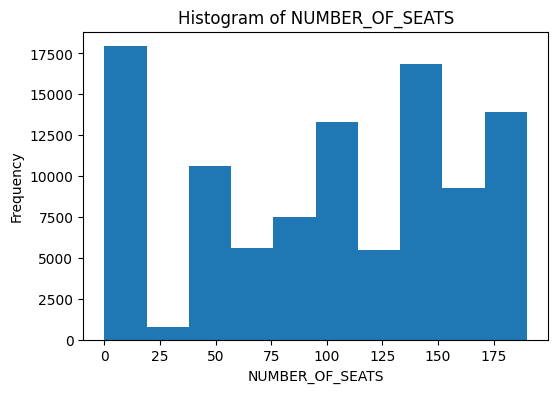

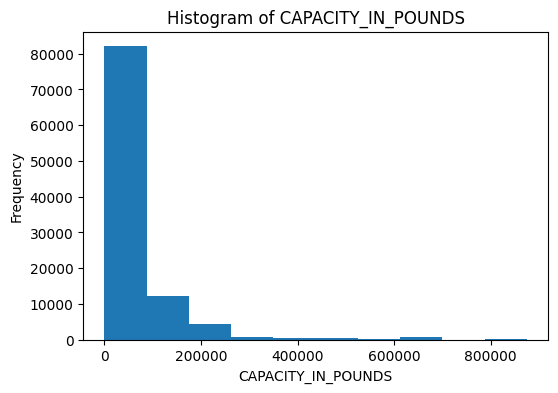

In [18]:
# histogram for NUMBER_OF_SEATS
plt.figure(figsize=(6,4))
plt.hist(inventory_final["NUMBER_OF_SEATS"])
plt.title("Histogram of NUMBER_OF_SEATS")
plt.xlabel("NUMBER_OF_SEATS")
plt.ylabel("Frequency")
plt.show()

# histogram for CAPACITY_IN_POUNDS
plt.figure(figsize=(6,4))
plt.hist(inventory_final["CAPACITY_IN_POUNDS"])
plt.title("Histogram of CAPACITY_IN_POUNDS")
plt.xlabel("CAPACITY_IN_POUNDS")
plt.ylabel("Frequency")
plt.show()

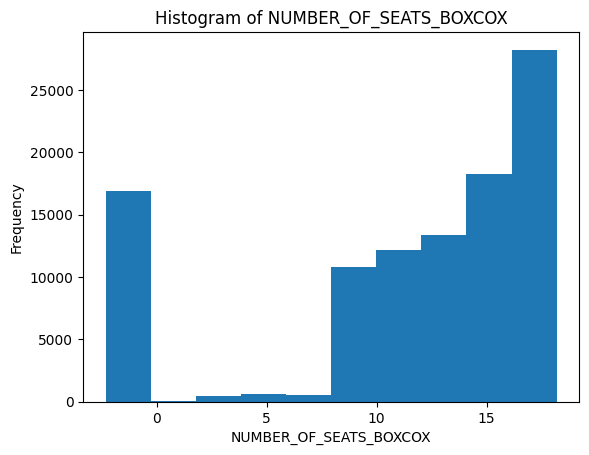

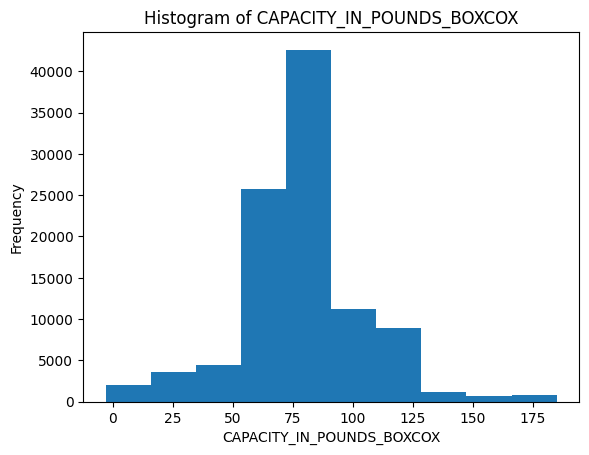

In [19]:
inventory_final["NUMBER_OF_SEATS_BOXCOX"],_= sps.boxcox(inventory_final["NUMBER_OF_SEATS"]+0.001)
inventory_final["CAPACITY_IN_POUNDS_BOXCOX"],_ = sps.boxcox(inventory_final["CAPACITY_IN_POUNDS"]+0.001)
plt.hist(inventory_final["NUMBER_OF_SEATS_BOXCOX"])
plt.title("Histogram of NUMBER_OF_SEATS_BOXCOX")
plt.xlabel("NUMBER_OF_SEATS_BOXCOX")
plt.ylabel("Frequency")
plt.show()

plt.hist(inventory_final["CAPACITY_IN_POUNDS_BOXCOX"])
plt.title("Histogram of CAPACITY_IN_POUNDS_BOXCOX")
plt.xlabel("CAPACITY_IN_POUNDS_BOXCOX")
plt.ylabel("Frequency")
plt.show()

Observation:
Before the transformation, the histgram for capacity in Pound is heavily right skewed. Most observations were concentrated at lower values, with a long tail extending to very large capacities. However, after the transformation, the distribution became much more symmetric and more concentrated around the center, so it appears more normal-like. For the histogram for the number of seats, although the transformation doesn't make it look perfectly normal, it is somewhat more compressed and smooth than before. 

5. Feature engineering

Create a new column SIZE by the quartiles of NUMBER_OF_SEATS
below 25% percentile: SMALL
25% - 50% percentile: MEDIUM
50% - 75% percentile: LARGE
above 75% percentile: XLARGE
For each size group, provide and plot the proportions of aircrafts that are operating versus not (OPERATING_STATUS).
For each size group, provide and plot the proportions of aircrafts belonging to each aircraft status group (AIRCRAFT_STATUS).
Provide a written summary of your findings.

In [20]:
# From the info table above, we know the quantile for number of seats 
q1 = 50
q2 = 108
q3 = 150
inventory_final["SIZE"] = ""
inventory_final.loc[inventory_final["NUMBER_OF_SEATS"] < q1, "SIZE"] = "SMALL"
inventory_final.loc[(inventory_final["NUMBER_OF_SEATS"] >= q1) & (inventory_final["NUMBER_OF_SEATS"] < q2), "SIZE"] = "MEDIUM"
inventory_final.loc[(inventory_final["NUMBER_OF_SEATS"] >= q2) & (inventory_final["NUMBER_OF_SEATS"] < q3), "SIZE"] = "LARGE"
inventory_final.loc[inventory_final["NUMBER_OF_SEATS"] >= q3, "SIZE"] = "XLARGE"

SIZE    OPERATING_STATUS
LARGE   N                   0.039759
        Y                   0.960241
MEDIUM  N                   0.053510
        Y                   0.946490
SMALL   N                   0.030846
        Y                   0.969154
XLARGE  N                   0.026840
        Y                   0.973160
dtype: float64


/var/folders/mk/n_ss_mb947xcn82pbzlqvzz00000gn/T/ipykernel_83174/1886819214.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="OPERATING_STATUS")


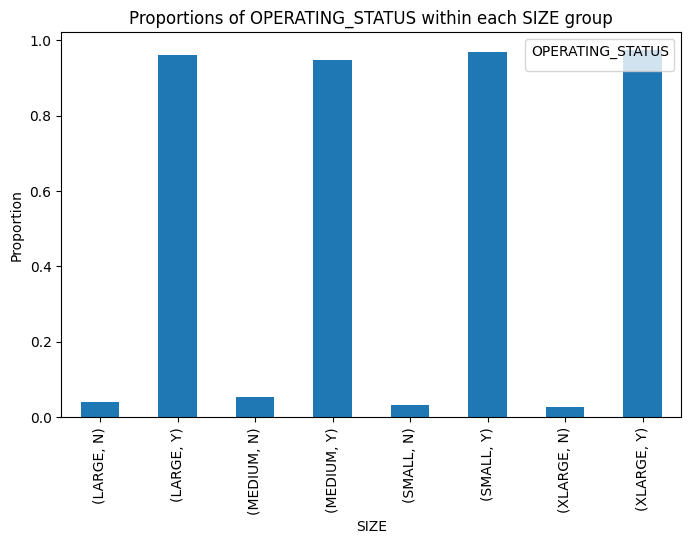

In [21]:
# plotting for each size group, provide and plot the proportions of aircrafts that are operating versus not (OPERATING_STATUS).
operating_count = inventory_final.groupby(["SIZE", "OPERATING_STATUS"]).size()
operating_prop = operating_count / inventory_final.groupby("SIZE").size()
print(operating_prop)
operating_prop.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Proportions of OPERATING_STATUS within each SIZE group")
plt.xlabel("SIZE")
plt.ylabel("Proportion")
plt.legend(title="OPERATING_STATUS")
plt.show()

SIZE    AIRCRAFT_STATUS
LARGE   A                  0.123548
        B                  0.200091
        L                  0.001909
        O                  0.674452
MEDIUM  A                  0.030836
        B                  0.563178
        O                  0.405986
SMALL   A                  0.037718
        B                  0.235366
        O                  0.726916
XLARGE  A                  0.087920
        B                  0.228803
        L                  0.002378
        O                  0.680898
dtype: float64


/var/folders/mk/n_ss_mb947xcn82pbzlqvzz00000gn/T/ipykernel_83174/3890068570.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="AIRCRAFT_STATUS")


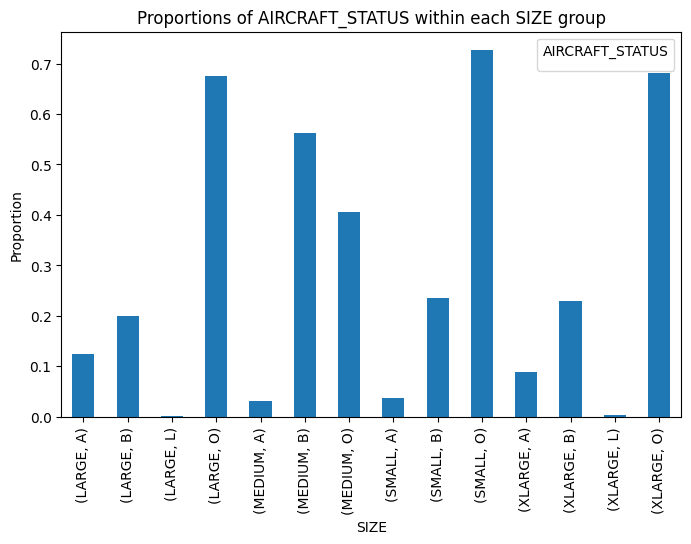

In [22]:
# For each size group, provide and plot the proportions of aircrafts belonging to each aircraft status group (AIRCRAFT_STATUS).
aircraft_prop = inventory_final.groupby(["SIZE", "AIRCRAFT_STATUS"]).size() / inventory_final.groupby("SIZE").size()
aircraft_prop.plot(kind="bar", stacked=True, figsize=(8,5))
print(aircraft_prop)
plt.title("Proportions of AIRCRAFT_STATUS within each SIZE group")
plt.xlabel("SIZE")
plt.ylabel("Proportion")
plt.legend(title="AIRCRAFT_STATUS")
plt.show()

For OPERATING_STATUS, the proportion of operating aircraft (Y) is very high in every size group, always above 94%. Among the four groups, XLARGE aircraft have the highest operating proportion, while MEDIUM aircraft have the lowest.

For AIRCRAFT_STATUS, category O has the highest proportion in every size group, while category L appears very rarely. SMALL, LARGE, and XLARGE aircraft are dominated by status O, whereas MEDIUM aircraft have a relatively lower share of O and a higher share of B.
Overall, most aircraft are operating regardless of size, and aircraft status patterns are broadly similar across size groups, although MEDIUM aircraft look somewhat different from the others.

6. Modeling refresher

Randomly split your data into 80% training and 20% testing data.
Create four models in total:
Predict NUMBER_OF_SEATS with a multivariate regression model.
Predict CAPACITY_IN_POUNDS with a multivariate regression model.
Predict NUMBER_OF_SEATS with a random forest model.
Predict CAPACITY_IN_POUNDS with a random forest model.
Report the training and testing error (RMSE). Comment on your observation about their performances.

In [ ]:
# Import the package
# Here we use numerical predictor for training. I am thinking about using get_dummies() function to include other categorical columns for the prediction
# but make kernal crash everytime when I run it. Therefore, I only include the numerical predictor here
from sklearn.model_selection import train_test_split
X_seats = inventory_final[["YEAR", "MANUFACTURE_YEAR", "CAPACITY_IN_POUNDS", "AIRLINE_ID"]]
y_seats = inventory_final["NUMBER_OF_SEATS"]

X_train_seats, X_test_seats, y_train_seats, y_test_seats = train_test_split(
    X_seats, y_seats, test_size=0.2)

In [31]:
# predict NUMBER_OF_SEATS
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

lr_seats = LinearRegression()
lr_seats.fit(X_train_seats, y_train_seats)

y_train_pred_lr_seats = lr_seats.predict(X_train_seats)
y_test_pred_lr_seats = lr_seats.predict(X_test_seats)

train_rmse_lr_seats = np.sqrt(mean_squared_error(y_train_seats, y_train_pred_lr_seats))
test_rmse_lr_seats = np.sqrt(mean_squared_error(y_test_seats, y_test_pred_lr_seats))

print("Linear Regression NUMBER_OF_SEATS train RMSE:", train_rmse_lr_seats)
print("Linear Regression NUMBER_OF_SEATS test RMSE:", test_rmse_lr_seats)

Linear Regression NUMBER_OF_SEATS train RMSE: 55.533263875883584
Linear Regression NUMBER_OF_SEATS test RMSE: 56.024582495551925


In [33]:
# Predict Number of seat using random forest
from sklearn.ensemble import RandomForestRegressor

rf_seats = RandomForestRegressor()
rf_seats.fit(X_train_seats, y_train_seats)

y_train_pred_rf_seats = rf_seats.predict(X_train_seats)
y_test_pred_rf_seats = rf_seats.predict(X_test_seats)

train_rmse_rf_seats = np.sqrt(mean_squared_error(y_train_seats, y_train_pred_rf_seats))
test_rmse_rf_seats = np.sqrt(mean_squared_error(y_test_seats, y_test_pred_rf_seats))

print("Random Forest NUMBER_OF_SEATS train RMSE:", train_rmse_rf_seats)
print("Random Forest NUMBER_OF_SEATS test RMSE:", test_rmse_rf_seats)

Random Forest NUMBER_OF_SEATS train RMSE: 7.35187122588303
Random Forest NUMBER_OF_SEATS test RMSE: 8.801090205461804


In [34]:
# predict Capacity_in_pounds
X_capacity = inventory_final[["YEAR", "MANUFACTURE_YEAR", "NUMBER_OF_SEATS", "AIRLINE_ID"]]
y_capacity = inventory_final["CAPACITY_IN_POUNDS"]

X_train_capacity, X_test_capacity, y_train_capacity, y_test_capacity = train_test_split(
    X_capacity, y_capacity, test_size=0.2)


In [35]:
lr_capacity = LinearRegression()
lr_capacity.fit(X_train_capacity, y_train_capacity)

y_train_pred_lr_capacity = lr_capacity.predict(X_train_capacity)
y_test_pred_lr_capacity = lr_capacity.predict(X_test_capacity)

train_rmse_lr_capacity = np.sqrt(mean_squared_error(y_train_capacity, y_train_pred_lr_capacity))
test_rmse_lr_capacity = np.sqrt(mean_squared_error(y_test_capacity, y_test_pred_lr_capacity))

print("Linear Regression CAPACITY_IN_POUNDS train RMSE:", train_rmse_lr_capacity)
print("Linear Regression CAPACITY_IN_POUNDS test RMSE:", test_rmse_lr_capacity)

Linear Regression CAPACITY_IN_POUNDS train RMSE: 88074.41120023967
Linear Regression CAPACITY_IN_POUNDS test RMSE: 88672.26625289554


In [36]:
rf_capacity = RandomForestRegressor()
rf_capacity.fit(X_train_capacity, y_train_capacity)

y_train_pred_rf_capacity = rf_capacity.predict(X_train_capacity)
y_test_pred_rf_capacity = rf_capacity.predict(X_test_capacity)

train_rmse_rf_capacity = np.sqrt(mean_squared_error(y_train_capacity, y_train_pred_rf_capacity))
test_rmse_rf_capacity = np.sqrt(mean_squared_error(y_test_capacity, y_test_pred_rf_capacity))

print("Random Forest CAPACITY_IN_POUNDS train RMSE:", train_rmse_rf_capacity)
print("Random Forest CAPACITY_IN_POUNDS test RMSE:", test_rmse_rf_capacity)

Random Forest CAPACITY_IN_POUNDS train RMSE: 22716.46994448092
Random Forest CAPACITY_IN_POUNDS test RMSE: 25772.328440797795


In [37]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression - NUMBER_OF_SEATS",
        "Random Forest - NUMBER_OF_SEATS",
        "Linear Regression - CAPACITY_IN_POUNDS",
        "Random Forest - CAPACITY_IN_POUNDS"
    ],
    "Train RMSE": [
        train_rmse_lr_seats,
        train_rmse_rf_seats,
        train_rmse_lr_capacity,
        train_rmse_rf_capacity
    ],
    "Test RMSE": [
        test_rmse_lr_seats,
        test_rmse_rf_seats,
        test_rmse_lr_capacity,
        test_rmse_rf_capacity
    ]
})

print(results)

                                    Model    Train RMSE     Test RMSE
0     Linear Regression - NUMBER_OF_SEATS     55.533264     56.024582
1         Random Forest - NUMBER_OF_SEATS      7.351871      8.801090
2  Linear Regression - CAPACITY_IN_POUNDS  88074.411200  88672.266253
3      Random Forest - CAPACITY_IN_POUNDS  22716.469944  25772.328441


The random forest models achieved much lower RMSE values than the linear regression models for both NUMBER_OF_SEATS and CAPACITY_IN_POUNDS, so they performed better overall. The linear regression models had similar training and testing RMSE, suggesting stable but weaker performance. The random forest models had slightly larger testing RMSE than training RMSE, indicating mild overfitting, but they still provided much more accurate predictions than linear regression.